# **Gobernanza**

Por: Daning Montaño

# **1. Librerías**

In [1]:
suppressMessages({library(ggplot2)
library(dplyr)
library(lubridate)
library(bslib)
source("Functions/plot_themes.R")
library(stringr)
library(plotly)
library(tidyr)
library(htmlwidgets)
library(dygraphs)
library(xts)
library(tidyverse)
library(googleVis)
library(scales)
library(tidytext)
library(igraph)
library(ggraph)
library(wordcloud)
library(vegan)
library(stringi)})

There were 15 warnings (use warnings() to see them)


# **2. Carga de datos**

In [2]:
Asambleas_0 = read.csv("../Data/Asambleas.csv")
Asambleas_0$Fecha = as.Date(Asambleas_0$Fecha, format = "%Y-%m-%d")
Mingas_0 = read.csv("../Data/Mingas.csv")
Mingas_0$Fecha = as.Date(Mingas_0$Fecha, format = "%Y-%m-%d")
Capacitaciones = read.csv("../Data/Capacitaciones.csv")
Capacitaciones$Fecha = as.Date(Capacitaciones$Fecha, format = "%Y-%m-%d")

# **3. Análisis de datos**

## 3.1 Trabajo de comunidades

In [3]:


# 1. Contamos las frecuencias en cada dataset
conteo_asambleas <- Asambleas_0 %>% 
  count(Comunidad, name = "Total_Asambleas")

conteo_mingas <- Mingas_0 %>% 
  count(Comunidad, name = "Total_Mingas")

conteo_capacitaciones <- Capacitaciones %>% 
  count(Comunidad, name = "Total_Capacitaciones")

# 2. Unimos los conteos usando full_join para no perder ninguna comunidad
# y reemplazamos los NA (donde no hubo actividad) por 0
resumen_comunidades <- conteo_asambleas %>%
  full_join(conteo_mingas, by = "Comunidad") %>%
  full_join(conteo_capacitaciones, by = "Comunidad") %>%
  mutate(across(starts_with("Total"), ~replace_na(., 0)))
#resumen_comunidades$Total_actividades = resumen_comunidades$Total_Asambleas + resumen_comunidades$Total_Mingas + resumen_comunidades$Total_Capacitaciones
# Ver el resultado
print(resumen_comunidades)

    Comunidad Total_Asambleas Total_Mingas Total_Capacitaciones
1     Napurak               7           19                    0
2 Sharamentsa              24          163                   52
3  Shuinmamus               1            7                    0
4  Wayusentsa              24           72                    3


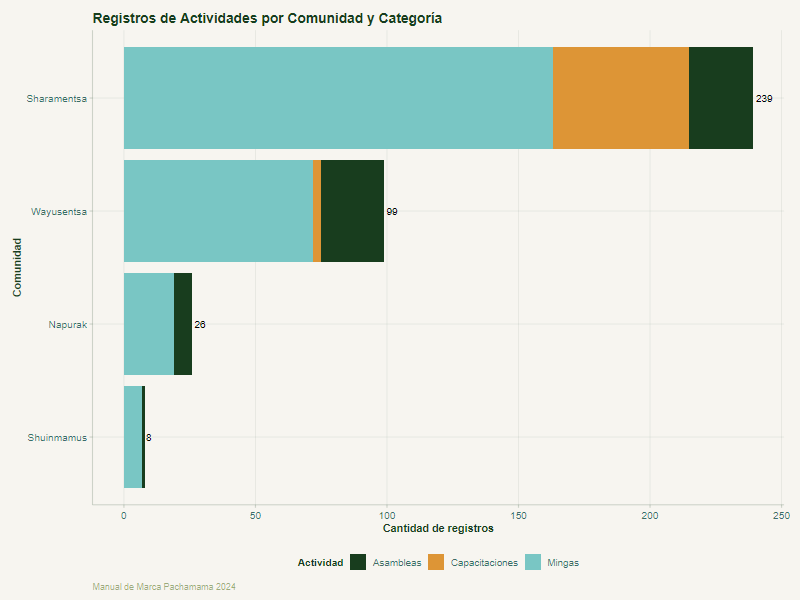

In [4]:

# 1. Aseguramos que el formato 'long' sea correcto
conteo_long <- resumen_comunidades %>%
  # Pasamos de ancho a largo. 'Cantidad' se crea aquí explícitamente.
  pivot_longer(
    cols = starts_with("Total"), 
    names_to = "Actividad", 
    values_to = "Cantidad" 
  ) %>%
  mutate(Actividad = gsub("Total_", "", Actividad)) %>%
  rename(Comunidad = Comunidad) # Aseguramos 'Comunidad' con C mayúscula

# 2. Ahora sí preparamos el conteo para la gráfica
conteo_grafico <- conteo_long %>%
  group_by(Comunidad) %>%
  mutate(Total_Comunidad = sum(Cantidad, na.rm = TRUE)) %>% # Suma segura
  ungroup()

# 3. Gráfica corregida
ggplot(conteo_grafico, aes(x = reorder(Comunidad, Cantidad, sum), y = Cantidad, fill = Actividad)) +
  geom_col() + 
  geom_text(
    aes(y = Total_Comunidad, label = Total_Comunidad),
    hjust = -0.2,            
    size = 3.5,              
    color = "black",         
    check_overlap = TRUE,    
    data = subset(conteo_grafico, !duplicated(Comunidad)) 
  ) +
  coord_flip(clip = "off") + 
  scale_fill_pacha() + 
  labs(
    title = "Registros de Actividades por Comunidad y Categoría",
    x = "Comunidad",
    y = "Cantidad de registros",
    fill = "Actividad",
    caption = "Manual de Marca Pachamama 2024"
  ) +
  theme_pachamama() + 
  theme(
    text = element_text(family = "sans"),
    legend.position = "bottom"
  )

## 3.2. Mingas

### Serie de tiempo - Registros

Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was generated. 


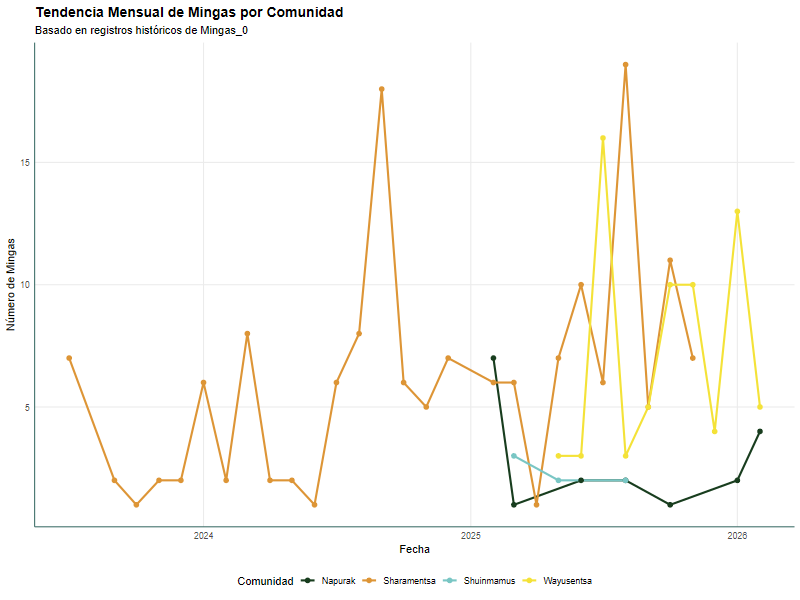

In [5]:

# 1. Preparar los datos (Usamos el objeto mingas_comunidad_mes antes del pivot_wider)
# Es más fácil graficar en ggplot con datos en formato "long" (largo)
data_plot <- Mingas_0 %>%
  mutate(Mes = floor_date(Fecha, "month")) %>%
  group_by(Mes, Comunidad) %>%
  summarise(Total = n(), .groups = 'drop')

# 2. Crear el gráfico estático
plot_estatico_mingas <- ggplot(data_plot, aes(x = Mes, y = Total, color = Comunidad)) +
  # Añadimos las líneas y los puntos
  geom_line(size = 1) +
  geom_point(size = 2) +
  # Configuración de colores (usando tu paleta si está definida, o una por defecto)
  scale_color_manual(values = as.character(PAL_CUAL)) +
  # Títulos y etiquetas
  labs(
    title = "Tendencia Mensual de Mingas por Comunidad",
    subtitle = "Basado en registros históricos de Mingas_0",
    x = "Fecha",
    y = "Número de Mingas",
    color = "Comunidad"
  ) +
  # Estética del tema
  theme_minimal() +
  theme(
    legend.position = "bottom",
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "#3c6d67"),
    plot.title = element_text(face = "bold", size = 14)
  )
  plot_estatico_mingas

### Participación por Género

Warning messages:
1: Removed 180 rows containing non-finite outside the scale range (`stat_ydensity()`). 
2: Removed 180 rows containing missing values or values outside the scale range (`geom_point()`). 


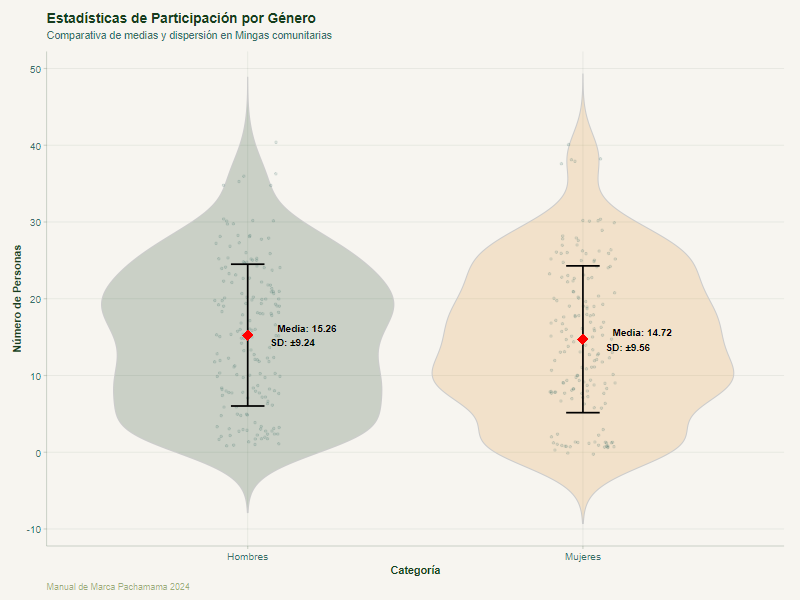

In [6]:

# 1. Pre-procesamiento de datos y cálculo de estadísticos
resumen_stats <- Mingas_0 %>%
  select(Numero_hombres, Numero_mujeres) %>%
  pivot_longer(cols = everything(), names_to = "Genero", values_to = "Cantidad") %>%
  mutate(Genero = if_else(Genero == "Numero_hombres", "Hombres", "Mujeres")) %>%
  group_by(Genero) %>%
  summarise(
    Media = mean(Cantidad, na.rm = TRUE),
    SD = sd(Cantidad, na.rm = TRUE),
    .groups = 'drop'
  )

mingas_long <- Mingas_0 %>%
  select(Numero_hombres, Numero_mujeres) %>%
  pivot_longer(cols = everything(), names_to = "Genero", values_to = "Cantidad") %>%
  mutate(Genero = if_else(Genero == "Numero_hombres", "Hombres", "Mujeres"))

# 2. Gráfica de Violín con Puntos, Métricas y Etiquetas de Texto
ggplot(mingas_long, aes(x = Genero, y = Cantidad, fill = Genero)) +
  # Fondo de Violín
  geom_violin(alpha = 0.2, color = "gray80", trim = FALSE) +
  
  # Puntos individuales (dispersión real)
  geom_point(position = position_jitter(width = 0.1), alpha = 0.15, color = "#3c6d67", size = 1) +
  
  # Barra de Desviación Estándar
  geom_errorbar(data = resumen_stats, 
                aes(y = Media, ymin = Media - SD, ymax = Media + SD), 
                width = 0.1, color = "black", linewidth = 0.8) +
  
  # Punto del Promedio (Rombo)
  geom_point(data = resumen_stats, aes(y = Media), 
             shape = 18, size = 5, color = "red") +
  
  # --- NUEVA CAPA: Etiquetas de texto con los valores ---
  geom_text(data = resumen_stats, 
            aes(y = Media, label = paste0("Media: ", round(Media, 2), 
                                          "\nSD: ±", round(SD, 2))),
            hjust = -0.5,      # Desplaza el texto a la derecha de la métrica
            vjust = 0.5,       # Centra verticalmente respecto al punto
            size = 3.5, 
            fontface = "bold",
            color = "black") +
  
  scale_fill_pacha() +
  labs(
    title = "Estadísticas de Participación por Género",
    subtitle = "Comparativa de medias y dispersión en Mingas comunitarias",
    x = "Categoría",
    y = "Número de Personas",
    caption = "Manual de Marca Pachamama 2024"
  ) +
  theme_pachamama() +
  theme(legend.position = "none")


### Trabajo hora x persona

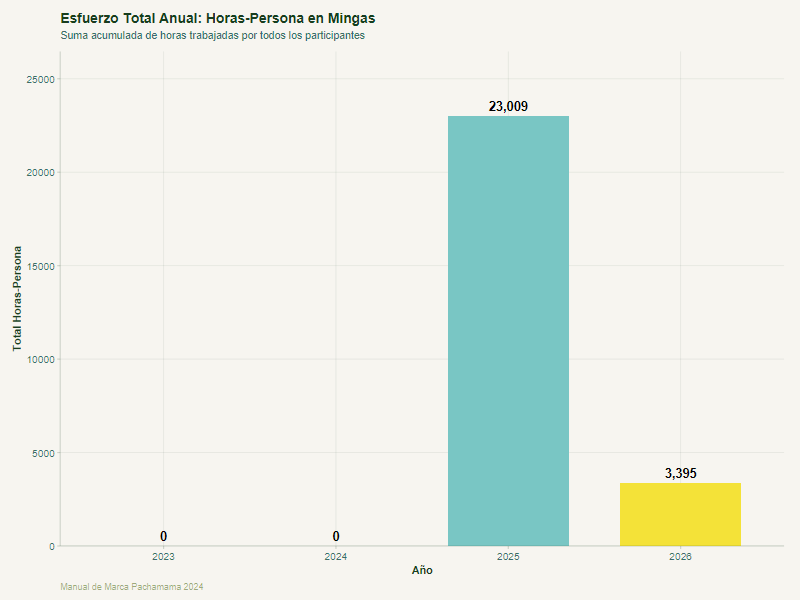

In [7]:

# 1. Preparar los datos anuales
horas_anuales <- Mingas_0 %>%
  #filter(Comunidad == "Wayusentsa")%>%
  mutate(
    # Calculamos horas-persona total por cada fila
    HP_fila = (Numero_mujeres + Numero_hombres) * Numero_horas_minga,
    # Extraemos el año
    Anio = as.factor(year(as.Date(Fecha)))
  ) %>%
  group_by(Anio) %>%
  summarise(Total_HP = sum(HP_fila, na.rm = TRUE), .groups = 'drop')

# 2. Generar el gráfico de barras
ggplot(horas_anuales, aes(x = Anio, y = Total_HP, fill = Anio)) +
  geom_col(width = 0.7, show.legend = FALSE) +
  # Etiquetas sobre las barras para lectura rápida
  geom_text(aes(label = scales::comma(Total_HP)), 
            vjust = -0.5, 
            fontface = "bold", 
            size = 4.5) +
  scale_fill_pacha() + # Colores institucionales
  labs(
    title = "Esfuerzo Total Anual: Horas-Persona en Mingas",
    subtitle = "Suma acumulada de horas trabajadas por todos los participantes",
    x = "Año",
    y = "Total Horas-Persona",
    caption = "Manual de Marca Pachamama 2024"
  ) +
  # Ajustar el límite superior para que no se corte la etiqueta
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  theme_pachamama() +
  theme(text = element_text(family = "sans"))

### Ratio participación hombre /mujer

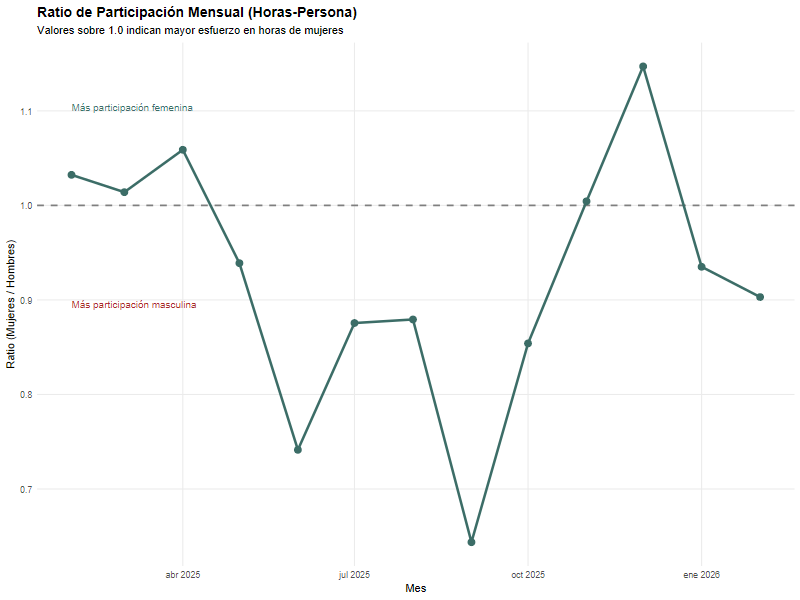

In [8]:


# 1. Preparación de datos y cálculo del Ratio
datos_ratio <- Mingas_0 %>%
  mutate(
    HP_Mujer = Numero_mujeres * Numero_horas_minga,
    HP_Hombre = Numero_hombres * Numero_horas_minga,
    Mes = floor_date(as.Date(Fecha), "month")
  ) %>%
  group_by(Mes) %>%
  summarise(
    Total_Mujeres = sum(HP_Mujer, na.rm = TRUE),
    Total_Hombres = sum(HP_Hombre, na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  mutate(
    # Calculamos el ratio (Mujeres / Hombres)
    # Usamos pmax para evitar división por cero si no hubo hombres en un mes
    Ratio = Total_Mujeres / pmax(Total_Hombres, 1) 
  )%>%
  filter(Ratio >0 )

# 2. Crear el gráfico de línea para el Ratio
plot_ratio_genero <- ggplot(datos_ratio, aes(x = Mes, y = Ratio)) +
  # Línea de referencia en 1 (Igualdad de participación)
  geom_hline(yintercept = 1, linetype = "dashed", color = "gray50", size = 0.8) +
  # Línea de tendencia y puntos
  geom_line(color = "#3c6d67", size = 1.2) +
  geom_point(color = "#3c6d67", size = 3) +
  # Anotaciones para facilitar la lectura
  annotate("text", x = min(datos_ratio$Mes), y = 1.1, label = "Más participación femenina", 
           hjust = 0, vjust = 0, size = 3.5, color = "#3c6d67") +
  annotate("text", x = min(datos_ratio$Mes), y = 0.9, label = "Más participación masculina", 
           hjust = 0, vjust = 1, size = 3.5, color = "brown") +
  # Estética y etiquetas
  labs(
    title = "Ratio de Participación Mensual (Horas-Persona)",
    subtitle = "Valores sobre 1.0 indican mayor esfuerzo en horas de mujeres",
    x = "Mes",
    y = "Ratio (Mujeres / Hombres)"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    panel.grid.minor = element_blank()
  )
  plot_ratio_genero

### Descripción de minga

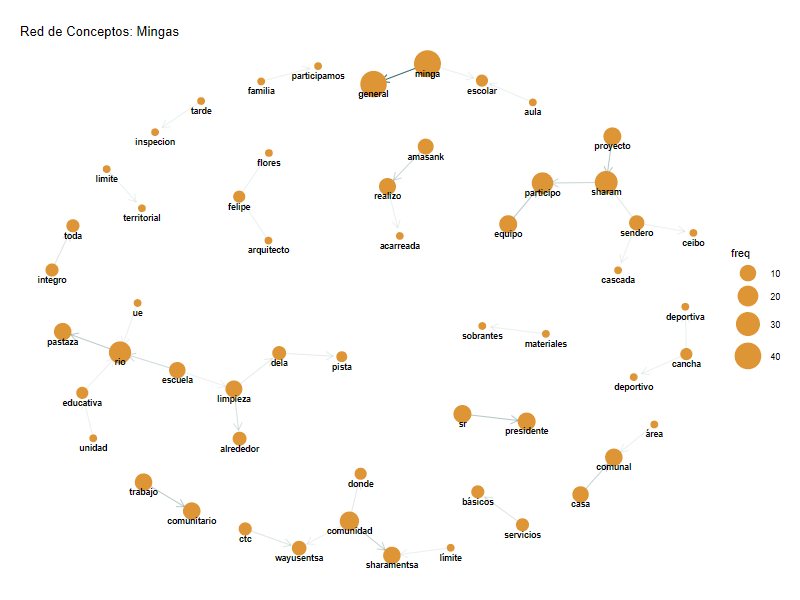

In [9]:
stop_words_es <- data.frame(word = c("de", "la", "el", "en", "y", "a", "los", "las", "un", "una", 
                                     "con", "por", "para", "se", "del", "al", "lo", "su", "es", "una", "mas", "que"))

# 2. Procesamiento con limpieza de NAs
red_datos <- Mingas_0 %>%
  filter(!is.na(Actividad_desarrollada_minga)) %>%
  mutate(texto = str_to_lower(Actividad_desarrollada_minga) %>% str_replace_all("[^[:alpha:][:space:]]", "")) %>%
  unnest_tokens(bigrama, texto, token = "ngrams", n = 2) %>%
  # Al separar, si una frase tenía una sola palabra, el segundo valor será NA
  separate(bigrama, c("p1", "p2"), sep = " ") %>%
  # ELIMINAR LOS NAs (Aquí es donde se soluciona el error)
  filter(!is.na(p1), !is.na(p2)) %>%
  # Quitar palabras sin significado
  filter(!p1 %in% stop_words_es$word, !p2 %in% stop_words_es$word) %>%
  count(p1, p2, sort = TRUE) %>%
  filter(n > 1)

# 3. Ahora sí, crear el objeto de red
red_objeto <- graph_from_data_frame(red_datos)
freq_nodos <- bind_rows(
  red_datos %>% select(word = p1, n),
  red_datos %>% select(word = p2, n)
) %>%
  group_by(word) %>%
  summarise(freq = sum(n), .groups = "drop")


# 4. Graficar
set.seed(123)
red_objeto <- graph_from_data_frame(red_datos)

V(red_objeto)$freq <- freq_nodos$freq[match(V(red_objeto)$name, freq_nodos$word)]


ggraph(red_objeto, layout = "kk") +
  geom_edge_link(
    aes(edge_alpha = n),
    edge_colour = PAL$rio,
    arrow = arrow(length = unit(3, "mm")),
    end_cap = circle(3, "mm"),
    show.legend = FALSE
  ) +
  geom_node_point(
    aes(size = freq),
    color = PAL$ave
  ) +
  geom_node_text(
    aes(label = name),
    vjust = 1.8,
    size = 3,
    fontface = "bold"
  ) +
  scale_size(range = c(3, 12)) +
  labs(
    title = "Red de Conceptos: Mingas",
  ) +
  theme_void() +
  theme(plot.margin = margin(20, 20, 20, 20))

### Homogenizar actividades

In [10]:

Mingas_0 <- Mingas_0 %>%
  mutate(
    Actividad_desarrollada_minga_limpia = Actividad_desarrollada_minga %>%
      str_squish() %>%
      str_to_lower() %>%
      stringi::stri_trans_general("Latin-ASCII"),
    
    grupo_minga = case_when(
      
      is.na(Actividad_desarrollada_minga_limpia) |
        Actividad_desarrollada_minga_limpia == "" ~ "Participación comunitaria general",
      
      # 1. Limpieza espacios
      str_detect(Actividad_desarrollada_minga_limpia,
                 "pista|sendero|trocha|camino|puerto|playa|patio|rio|cancha|caban|alrededor") ~
        "Limpieza de espacios comunitarios",
      
      # 2. Infraestructura comunitaria
      str_detect(Actividad_desarrollada_minga_limpia,
                 "oficina|casa comunal|casa comunidad|ctc|centro turismo|turistica|wayusentsa|lavanderia") ~
        "Infraestructura comunitaria",
      
      # 3. Escuela
      str_detect(Actividad_desarrollada_minga_limpia,
                 "escuela|unidad educativa|u\\.e|cecib|aula|educacion|institucion") ~
        "Infraestructura educativa",
      
      # 4. Producción
      str_detect(Actividad_desarrollada_minga_limpia,
                 "invernadero|huerta|platabanda|cernimiento") ~
        "Producción agrocomunitaria",
      
      # 5. Linderos
      str_detect(Actividad_desarrollada_minga_limpia,
                 "lindero|linderacion|linderasion|limite territorial|territorio") ~
        "Linderos y territorio",
      
      # 6. Agua y saneamiento
      str_detect(Actividad_desarrollada_minga_limpia,
                 "agua|captacion|servicios basicos|bateria sanitaria|bano|basura|paneles") ~
        "Agua y saneamiento",
      
      # 7. Construcción
      str_detect(Actividad_desarrollada_minga_limpia,
                 "construccion|reparacion|colocacion|poner|techo|cerramiento|ventana|mantenimiento|arreglo") ~
        "Construcción, mantenimiento y reparaciones",
      
      # 8. Acarreo
      str_detect(Actividad_desarrollada_minga_limpia,
                 "acarreada|acarreo|cargada|se cargo|cargar|madera|tablas|piedra|arena|materiales|tanque|tubos") ~
        "Acarreo y logística de materiales",
      
      # 9. Monitoreo
      str_detect(Actividad_desarrollada_minga_limpia,
                 "coordenada|puntos|inspecion|inspeccion|camara trampa|foto|video") ~
        "Monitoreo y levantamiento técnico",
      
      # 10. Participación general
      str_detect(Actividad_desarrollada_minga_limpia,
                 "minga general|trabajo comunitario|participacion|peticion del presidente") ~
        "Participación comunitaria general",
      
      TRUE ~ "Participación comunitaria general"
    )
  )

### Diversiad de actividades homologadas

In [11]:

# =========================================================
# 1. Horas-persona por fila
# =========================================================
Mingas_1 <- Mingas_0 %>%
  mutate(
    Total_personas = coalesce(Numero_hombres, 0) +
                     coalesce(Numero_mujeres, 0),
    
    Horas_persona = Total_personas * coalesce(Numero_horas_minga, 0),
    
    Mes = floor_date(as.Date(Fecha), "month")
  )

# =========================================================
# 2. Agregar esfuerzo mensual por tipo de actividad
# (usa tu variable ya homologada, ej: grupo_minga)
# =========================================================
esfuerzo_mensual <- Mingas_1 %>%
  filter(Horas_persona > 0, !is.na(Mes)) %>%
  group_by(Mes, grupo_minga) %>%
  summarise(
    Horas_persona = sum(Horas_persona, na.rm = TRUE),
    .groups = "drop"
  )

# =========================================================
# 3. Matriz Mes x Actividad
# =========================================================
matriz <- esfuerzo_mensual %>%
  pivot_wider(
    names_from = grupo_minga,
    values_from = Horas_persona,
    values_fill = 0
  )

# =========================================================
# 4. Shannon mensual
# =========================================================
shannon_mensual <- tibble(
  Mes = matriz$Mes,
  Shannon = vegan::diversity(
    as.matrix(select(matriz, -Mes)),
    index = "shannon"
  )
) %>%
  mutate(
    Hill_1 = exp(Shannon)
  )

shannon_mensual

# A tibble: 13 × 3
   Mes        Shannon Hill_1
   <date>       <dbl>  <dbl>
 1 2025-02-01   0.561   1.75
 2 2025-03-01   0.937   2.55
 3 2025-04-01   0       1   
 4 2025-05-01   0.966   2.63
 5 2025-06-01   1.50    4.49
 6 2025-07-01   1.14    3.13
 7 2025-08-01   1.37    3.93
 8 2025-09-01   1.05    2.86
 9 2025-10-01   1.18    3.26
10 2025-11-01   1.08    2.93
11 2025-12-01   0       1   
12 2026-01-01   1.34    3.82
13 2026-02-01   0.676   1.97

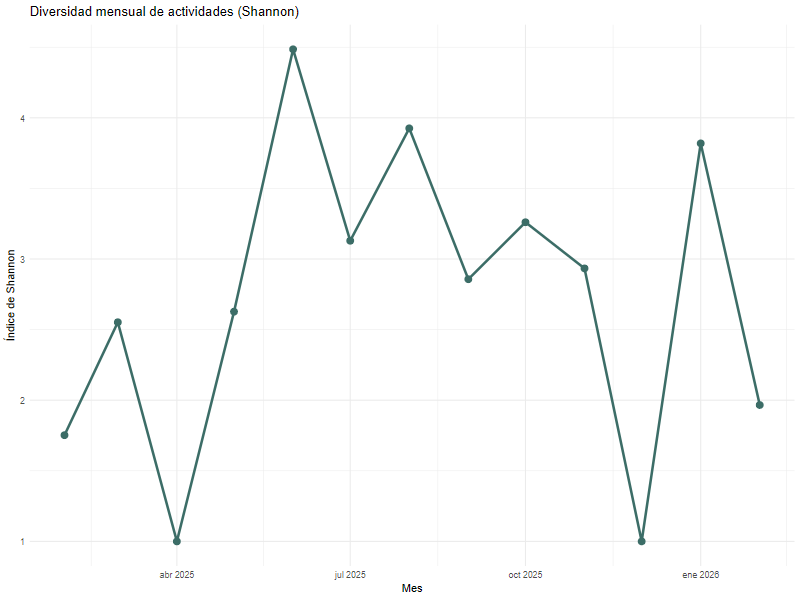

In [12]:
ggplot(shannon_mensual, aes(Mes, Hill_1)) +
  geom_line(linewidth = 1.2, color = "#3c6d67") +
  geom_point(size = 3, color = "#3c6d67") +
  labs(
    title = "Diversidad mensual de actividades (Shannon)",
    x = "Mes",
    y = "Índice de Shannon"
  ) +
  theme_minimal()

### Esfuerzo por actividad homologada

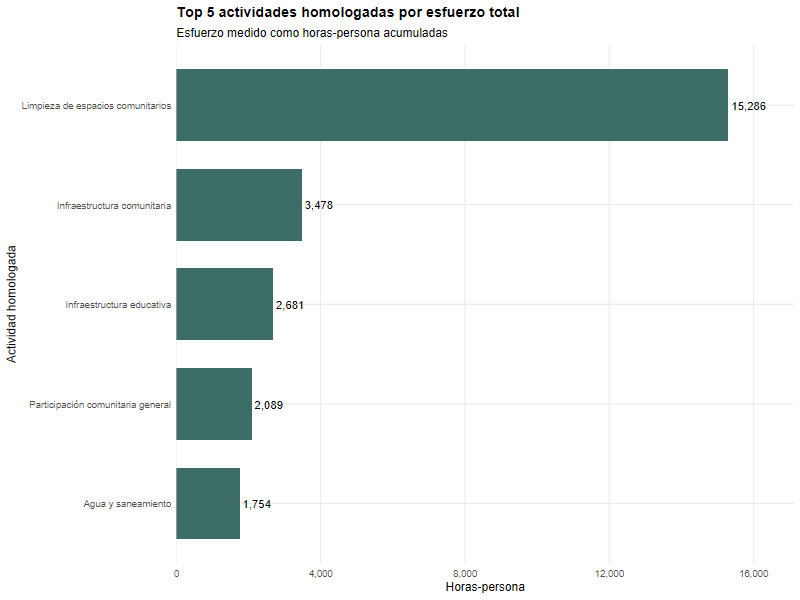

In [13]:

# =========================================================
# 1. Calcular esfuerzo total por actividad homologada
# =========================================================
esfuerzo_actividad <- Mingas_0 %>%
  mutate(
    Total_personas = coalesce(Numero_hombres, 0) +
                     coalesce(Numero_mujeres, 0),
    Horas_persona = Total_personas * coalesce(Numero_horas_minga, 0)
  ) %>%
  group_by(grupo_minga) %>%
  summarise(
    Esfuerzo_total = sum(Horas_persona, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(Esfuerzo_total))

esfuerzo_actividad

# =========================================================
# 2. Top 5 actividades homologadas
# =========================================================
top5_esfuerzo <- esfuerzo_actividad %>%
  slice_max(order_by = Esfuerzo_total, n = 5, with_ties = FALSE) %>%
  mutate(grupo_minga = fct_reorder(grupo_minga, Esfuerzo_total))

top5_esfuerzo

# =========================================================
# 3. Gráfico de barras
# =========================================================
ggplot(top5_esfuerzo, aes(x = grupo_minga, y = Esfuerzo_total)) +
  geom_col(fill = "#3c6d67", width = 0.72) +
  coord_flip() +
  geom_text(
    aes(label = comma(Esfuerzo_total)),
    hjust = -0.1,
    size = 4
  ) +
  scale_y_continuous(
    labels = comma,
    expand = expansion(mult = c(0, 0.12))
  ) +
  labs(
    title = "Top 5 actividades homologadas por esfuerzo total",
    subtitle = "Esfuerzo medido como horas-persona acumuladas",
    x = "Actividad homologada",
    y = "Horas-persona"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )

### Índice de Cohesión en el Trabajo Comunitario (ICTC)

In [14]:
# Convertimos a numérico y manejamos NAs para asegurar que las sumas funcionen
Mingas_limpio <- Mingas_1 %>%
  mutate(
    Numero_hombres = as.numeric(replace_na(as.character(Numero_hombres), "0")),
    Numero_mujeres = as.numeric(replace_na(as.character(Numero_mujeres), "0")),
    Total_personas = Numero_hombres + Numero_mujeres,
    # Aseguramos que la fecha sea reconocida como tal
    Fecha = as.Date(Fecha)
  )

ICTC_resultado <- Mingas_limpio %>%
  summarise(
    Total_Mingas = n(),
    Promedio_Participacion = mean(Total_personas, na.rm = TRUE),
    Total_Hombres = sum(Numero_hombres),
    Total_Mujeres = sum(Numero_mujeres)
  )

print("Índice de Cohesión (ICTC):")
print(ICTC_resultado)

[1] "Índice de Cohesión (ICTC):"
  Total_Mingas Promedio_Participacion Total_Hombres Total_Mujeres
1          261               19.65134          2686          2443


### Efectividad de Respuesta a la Gobernanza (ERG)

In [15]:
ERG_resultado <- Mingas_limpio %>%
  mutate(
    por_mandato = str_detect(tolower(Actividad_desarrollada_minga), 
                             "petición|pedido|presidente|autoridad")
  ) %>%
  summarise(
    Mingas_por_Mandato = sum(por_mandato, na.rm = TRUE),
    Total_Mingas = n(),
    Porcentaje_ERG = (Mingas_por_Mandato / Total_Mingas) * 100
  )

print("Efectividad de Respuesta a la Gobernanza (ERG %):")
print(ERG_resultado)

[1] "Efectividad de Respuesta a la Gobernanza (ERG %):"
  Mingas_por_Mandato Total_Mingas Porcentaje_ERG
1                 21          261       8.045977


### Índice de Mantenimiento de Linderos y Vigilancia (IMLV) ---


In [16]:
IMLV_resultado <- Mingas_limpio %>%
  filter(grupo_minga == "Linderos y territorio") %>%
  summarise(
    Numero_Acciones_Vigilancia = n(),
    Esfuerzo_Total_Horas = sum(as.numeric(replace_na(as.character(Numero_horas_minga), "0")), na.rm = TRUE)
  )

print("Índice de Mantenimiento de Linderos (IMLV):")
print(IMLV_resultado)

[1] "Índice de Mantenimiento de Linderos (IMLV):"
  Numero_Acciones_Vigilancia Esfuerzo_Total_Horas
1                         11                   53


## 3.3. Asambleas

Deberiamos revisar cuanto tiempo de la asamblea le dedican a conservación

In [17]:
Asambleas_0$Decision_principal

 [1] "Realizo la reunión extra ordinaria con la comunidad."                                                                                                                                                                                                   
 [2] "Asamblea para socialización de la creación de nuevo colegio particular Waldor."                                                                                                                                                                         
 [3] "Asamblea extraordinaria de la comunidad achuar Sharamentsa."                                                                                                                                                                                            
 [4] "Asamblea extraordinaria de la comunidad Achuar Sharamentsa"                                                                                                                                                                          

### Serie de tiempo

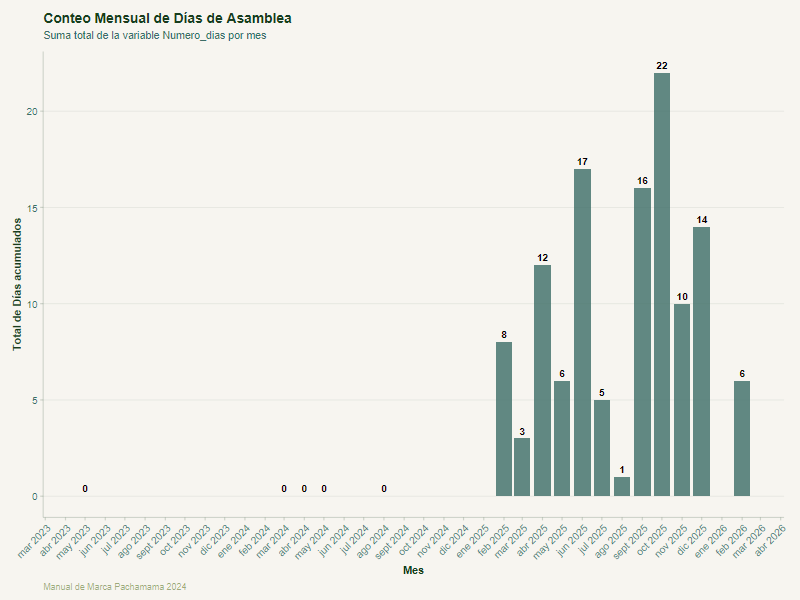

In [18]:

# 1. Preparar los datos: Conteo de Numero_dias por mes
asambleas_mensual <- Asambleas_0 %>%
  mutate(Mes = floor_date(as.Date(Fecha), "month")) %>%
  group_by(Mes) %>%
  summarise(Total_Dias = sum(Numero_dias, na.rm = TRUE), .groups = 'drop')

# 2. Generar la gráfica de barras mensuales
ggplot(asambleas_mensual, aes(x = Mes, y = Total_Dias)) +
  # Usamos un color sólido de tu paleta institucional
  geom_col(fill = "#3c6d67", alpha = 0.8) + 
  # Etiquetas sobre las barras para ver el conteo exacto
  geom_text(aes(label = Total_Dias), vjust = -0.5, size = 3.5, fontface = "bold") +
  # Escala de fecha para que se lea "Ene 2024", etc.
  scale_x_date(date_labels = "%b %Y", date_breaks = "1 month") +
  labs(
    title = "Conteo Mensual de Días de Asamblea",
    subtitle = "Suma total de la variable Numero_dias por mes",
    x = "Mes",
    y = "Total de Días acumulados",
    caption = "Manual de Marca Pachamama 2024"
  ) +
  theme_pachamama() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1), # Inclinamos fechas para legibilidad
    panel.grid.major.x = element_blank()
  )

In [19]:
# 1. Preparar los datos con corrección de NA a 1 para los existentes
asambleas_discontinuas <- Asambleas_0 %>%
  mutate(
    Mes = floor_date(as.Date(Fecha), "month"),
    Dias_Corregidos = replace_na(Numero_dias, 1)
  ) %>%
  group_by(Mes) %>%
  summarise(Total_Dias = sum(Dias_Corregidos, na.rm = TRUE))

# 2. Crear un calendario completo de meses para detectar los huecos
# Esto es vital para que dygraphs sepa dónde NO debe dibujar líneas
rango_fechas <- seq(min(asambleas_discontinuas$Mes), 
                    max(asambleas_discontinuas$Mes), 
                    by = "month")

df_completo <- data.frame(Mes = rango_fechas) %>%
  left_join(asambleas_discontinuas, by = "Mes") 
  # NOTA: No usamos replace_na(0) aquí. Dejamos los Total_Dias como NA 
  # para que dygraphs rompa la línea.

# 3. Convertir a objeto xts
don_pacha_gap <- xts(df_completo$Total_Dias, order.by = df_completo$Mes)
colnames(don_pacha_gap) <- "Dias_Asamblea"

# 4. Generar la serie de tiempo con "puntos sueltos"
plot_asambleas_interactivo = dygraph(don_pacha_gap, main = "Días de Asamblea (Solo meses con actividad)") %>%
  dyOptions(
    labelsUTC = FALSE, 
    drawPoints = TRUE,          # Dibujamos puntos para ver los meses aislados
    pointSize = 4,
    connectSeparatedPoints = FALSE, # ¡ESTA ES LA CLAVE! Evita unir puntos lejanos
    fillGraph = FALSE,          # Quitamos el relleno para que se note la discontinuidad
    colors = "#3c6d67",
    strokeWidth = 2,
    axisLineColor = "#3c6d67"
  ) %>%
  dyRangeSelector(height = 40, strokeColor = PAL$rio, fillColor = PAL$cielo) %>%
  dyAxis("y", label = "Días de Asamblea") %>%
  dyLegend(show = "always")

# Visualizar


saveWidget(plot_asambleas_interactivo, "Plots/Serie_Temporal_Interactivo_Pachamama_asambleas.html", selfcontained = TRUE)

### Participación de personas x minga

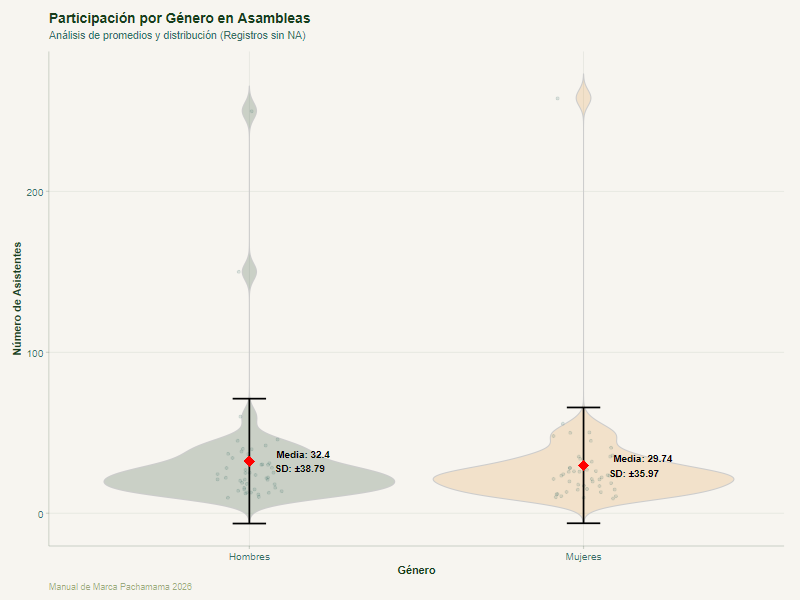

In [20]:
# 1. Pre-procesamiento: Limpieza de NAs y cálculo de estadísticos
# Filtramos primero para que las medias y desviaciones sean precisas
asambleas_limpias <- Asambleas_0 %>%
  select(Numero_hombres, Numero_mujeres) %>%
  drop_na(Numero_hombres, Numero_mujeres) # Eliminamos filas con NA en estas columnas

resumen_stats_asambleas <- asambleas_limpias %>%
  pivot_longer(cols = everything(), names_to = "Genero", values_to = "Cantidad") %>%
  mutate(Genero = if_else(Genero == "Numero_hombres", "Hombres", "Mujeres")) %>%
  group_by(Genero) %>%
  summarise(
    Media = mean(Cantidad),
    SD = sd(Cantidad),
    .groups = 'drop'
  )

asambleas_long <- asambleas_limpias %>%
  pivot_longer(cols = everything(), names_to = "Genero", values_to = "Cantidad") %>%
  mutate(Genero = if_else(Genero == "Numero_hombres", "Hombres", "Mujeres"))

# 2. Gráfica de Violín con Puntos, Métricas y Etiquetas (Datos de Asambleas)
ggplot(asambleas_long, aes(x = Genero, y = Cantidad, fill = Genero)) +
  # Fondo de Violín
  geom_violin(alpha = 0.2, color = "gray80", trim = FALSE) +
  
  # Puntos individuales (dispersión real de asambleas)
  geom_point(position = position_jitter(width = 0.1), alpha = 0.15, color = "#3c6d67", size = 1.2) +
  
  # Barra de Desviación Estándar (±1 SD)
  geom_errorbar(data = resumen_stats_asambleas, 
                aes(y = Media, ymin = Media - SD, ymax = Media + SD), 
                width = 0.1, color = "black", linewidth = 0.8) +
  
  # Punto del Promedio (Rombo rojo)
  geom_point(data = resumen_stats_asambleas, aes(y = Media), 
             shape = 18, size = 5, color = "red") +
  
  # Etiquetas de texto con los valores exactos
  geom_text(data = resumen_stats_asambleas, 
            aes(y = Media, label = paste0("Media: ", round(Media, 2), 
                                          "\nSD: ±", round(SD, 2))),
            hjust = -0.5, 
            vjust = 0.5, 
            size = 3.5, 
            fontface = "bold",
            color = "black") +
  
  scale_fill_pacha() + # Usando tu paleta institucional
  labs(
    title = "Participación por Género en Asambleas",
    subtitle = "Análisis de promedios y distribución (Registros sin NA)",
    x = "Género",
    y = "Número de Asistentes",
    caption = "Manual de Marca Pachamama 2026"
  ) +
  theme_pachamama() +
  theme(legend.position = "none")

### Tipo de Asamblea

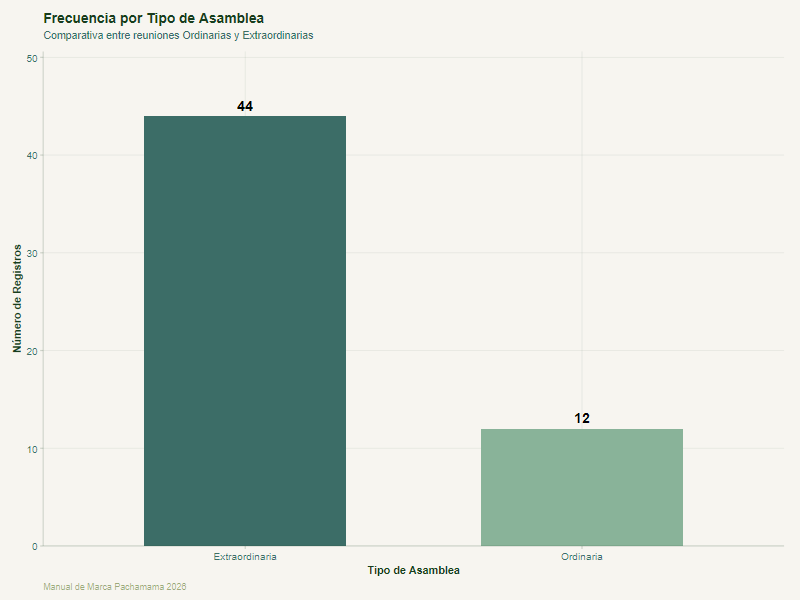

In [21]:

# 1. Preparar los datos: Contar frecuencias
resumen_tipo_asamblea <- Asambleas_0 %>%
  group_by(Tipo_asamblea) %>%
  summarise(Conteo = n(), .groups = 'drop') %>%
  # Limpieza opcional por si hay NAs o vacíos
  filter(!is.na(Tipo_asamblea) & Tipo_asamblea != "")

# 2. Generar la gráfica de barras
ggplot(resumen_tipo_asamblea, aes(x = reorder(Tipo_asamblea, -Conteo), y = Conteo, fill = Tipo_asamblea)) +
  geom_col(width = 0.6, show.legend = FALSE) +
  # Añadir etiquetas de valor sobre las barras
  geom_text(aes(label = Conteo), vjust = -0.5, fontface = "bold", size = 5) +
  # Usar colores institucionales (o manuales si prefieres)
  scale_fill_manual(values = c("Extraordinaria" = "#3c6d67", "Ordinaria" = "#89b399")) +
  labs(
    title = "Frecuencia por Tipo de Asamblea",
    subtitle = "Comparativa entre reuniones Ordinarias y Extraordinarias",
    x = "Tipo de Asamblea",
    y = "Número de Registros",
    caption = "Manual de Marca Pachamama 2026"
  ) +
  # Ajustar el eje Y para que la etiqueta no se corte
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  theme_pachamama()

### Decisión Asamblea

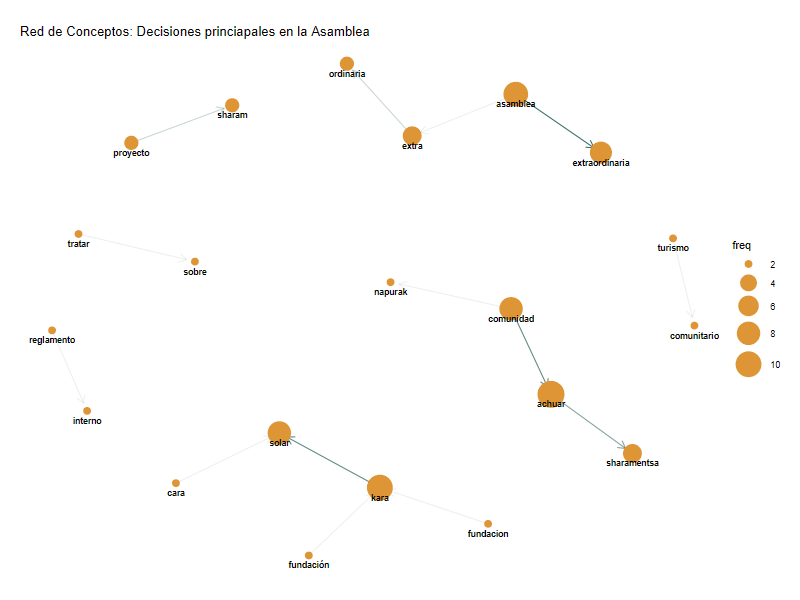

In [22]:
stop_words_es <- data.frame(word = c("de", "la", "el", "en", "y", "a", "los", "las", "un", "una", 
                                     "con", "por", "para", "se", "del", "al", "lo", "su", "es", "una", "mas", "que"))

# 2. Procesamiento con limpieza de NAs
red_datos <- Asambleas_0 %>%
  filter(!is.na(Decision_principal)) %>%
  mutate(texto = str_to_lower(Decision_principal) %>% str_replace_all("[^[:alpha:][:space:]]", "")) %>%
  unnest_tokens(bigrama, texto, token = "ngrams", n = 2) %>%
  # Al separar, si una frase tenía una sola palabra, el segundo valor será NA
  separate(bigrama, c("p1", "p2"), sep = " ") %>%
  # ELIMINAR LOS NAs (Aquí es donde se soluciona el error)
  filter(!is.na(p1), !is.na(p2)) %>%
  # Quitar palabras sin significado
  filter(!p1 %in% stop_words_es$word, !p2 %in% stop_words_es$word) %>%
  count(p1, p2, sort = TRUE) %>%
  filter(n > 1)

# 3. Ahora sí, crear el objeto de red
red_objeto <- graph_from_data_frame(red_datos)
freq_nodos <- bind_rows(
  red_datos %>% select(word = p1, n),
  red_datos %>% select(word = p2, n)
) %>%
  group_by(word) %>%
  summarise(freq = sum(n), .groups = "drop")


# 4. Graficar
set.seed(123)
red_objeto <- graph_from_data_frame(red_datos)

V(red_objeto)$freq <- freq_nodos$freq[match(V(red_objeto)$name, freq_nodos$word)]


ggraph(red_objeto, layout = "kk") +
  geom_edge_link(
    aes(edge_alpha = n),
    edge_colour = PAL$rio,
    arrow = arrow(length = unit(3, "mm")),
    end_cap = circle(3, "mm"),
    show.legend = FALSE
  ) +
  geom_node_point(
    aes(size = freq),
    color = PAL$ave
  ) +
  geom_node_text(
    aes(label = name),
    vjust = 1.8,
    size = 3,
    fontface = "bold"
  ) +
  scale_size(range = c(3, 12)) +
  labs(
    title = "Red de Conceptos: Decisiones princiapales en la Asamblea",
  ) +
  theme_void() +
  theme(plot.margin = margin(20, 20, 20, 20))

### Homologación de deciciones

In [23]:

Asambleas_0 <- Asambleas_0 %>%
  mutate(
    Decision_homologada = case_when(
      
      # 1. Gobernanza comunitaria (asambleas, reglamentos, acuerdos, socios)
      str_detect(Decision_principal, regex("asamblea|reunión|reglamento|socios|nombramiento|acuerdo|consejo", ignore_case = TRUE)) ~ 
        "Gobernanza comunitaria",
      
      # 2. Gestión y seguimiento de proyectos
      str_detect(Decision_principal, regex("proyecto|plan de inversión|seguimiento|ejecución|informe", ignore_case = TRUE)) ~ 
        "Gestión de proyectos",
      
      # 3. Educación y formación formal
      str_detect(Decision_principal, regex("colegio|cecib|educativa|docentes|preprimaria|útiles escolares", ignore_case = TRUE)) ~ 
        "Educación",
      
      # 4. Capacitación técnica y fortalecimiento de capacidades
      str_detect(Decision_principal, regex("capacitación|monitores|emprendimiento", ignore_case = TRUE)) ~ 
        "Capacitación",
      
      # 5. Conservación y ambiente
      str_detect(Decision_principal, regex("conservación|animales|naturaleza|jaguar", ignore_case = TRUE)) ~ 
        "Conservación",
      
      # 6. Infraestructura y obras
      str_detect(Decision_principal, regex("muelle|casa típica|aula típica", ignore_case = TRUE)) ~ 
        "Infraestructura",
      
      # 7. Energía y tecnología (Kara Solar, motores, innovación)
      str_detect(Decision_principal, regex("kara solar|motores|solar|eléctrico", ignore_case = TRUE)) ~ 
        "Energía y tecnología",
      
      # 8. Coordinación externa e institucional
      str_detect(Decision_principal, regex("fundación|convenio|periodista|nae|gobierno|gad", ignore_case = TRUE)) ~ 
        "Articulación institucional",
      
      # 9. Cultura, turismo y organización social
      str_detect(Decision_principal, regex("turismo|cultura|shamanismo|predicaciones", ignore_case = TRUE)) ~ 
        "Cultura y turismo",
      
      # 10. Temas generales multisectoriales
      str_detect(Decision_principal, regex("salud|territorio|política", ignore_case = TRUE)) ~ 
        "Gestión integral comunitaria",
      
      # 11. Vacíos o no clasificados
      Decision_principal == "" ~ 
        NA_character_,
      
      TRUE ~ "Otros"
    )
  )



### Personas por tipo de decisión

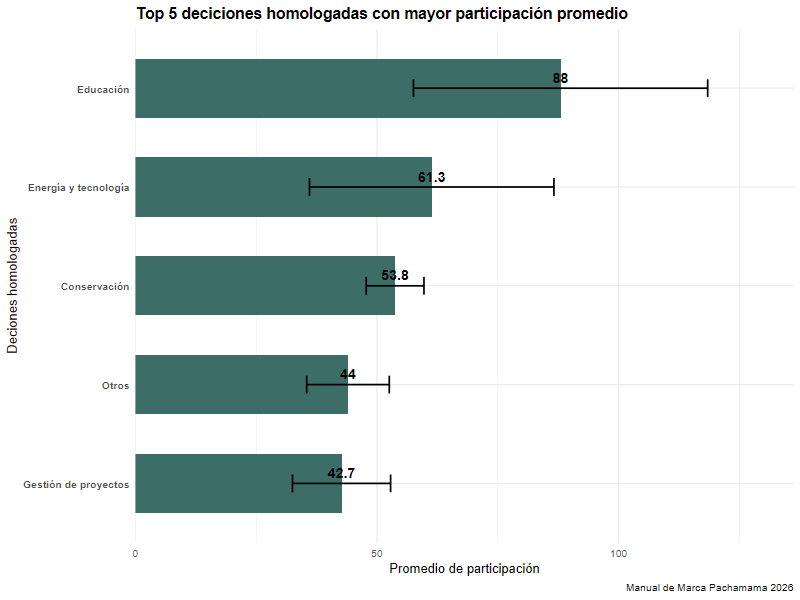

In [24]:
library(dplyr)
library(ggplot2)
library(forcats)

# ------------------------------------------------------------
# 1. Limpiar datos
# - eliminar duplicados por X_uuid
# - convertir conteos a numérico
# - sumar hombres + mujeres por fila
# ------------------------------------------------------------
Asambleas_0 <- Asambleas_0 %>%
  distinct(X_uuid, .keep_all = TRUE) %>%
  mutate(
    Numero_hombres = as.numeric(Numero_hombres),
    Numero_mujeres = as.numeric(Numero_mujeres),
    participacion_total = rowSums(
      cbind(Numero_hombres, Numero_mujeres),
      na.rm = TRUE
    )
  )

# ------------------------------------------------------------
# 2. Resumen por actividad homologada
# - eliminar categorías con solo 1 registro
# ------------------------------------------------------------
resumen_participacion <- Asambleas_0 %>%
  filter(
    !is.na(Decision_homologada),
    Decision_homologada != "",
    !is.na(participacion_total)
  ) %>%
  group_by(Decision_homologada) %>%
  summarise(
    Conteo = n(),
    Promedio = mean(participacion_total, na.rm = TRUE),
    SD = sd(participacion_total, na.rm = TRUE),
    EE = SD / sqrt(Conteo),
    .groups = "drop"
  ) %>%
  filter(Conteo > 1) %>%
  arrange(desc(Promedio))

# Tabla resumen
resumen_participacion

# ------------------------------------------------------------
# 3. Top 5 categorías con mayor promedio de participación
# ------------------------------------------------------------
top5_participacion <- resumen_participacion %>%
  slice_max(order_by = Promedio, n = 5, with_ties = FALSE) %>%
  mutate(
    Decision_homologada = fct_reorder(Decision_homologada, Promedio)
  )

top5_participacion

# ------------------------------------------------------------
# 4. Gráfico de barras con error estándar
# estilo adaptado al ejemplo que enviaste
# ------------------------------------------------------------
ggplot(
  top5_participacion,
  aes(
    x = reorder(Decision_homologada, Promedio),
    y = Promedio
  ), fill = "#3c6d67"
) +
  geom_col(width = 0.6, show.legend = FALSE,fill = "#3c6d67") +
  geom_errorbar(
    aes(
      ymin = Promedio - EE,
      ymax = Promedio + EE
    ),
    width = 0.18,
    linewidth = 0.8
  ) +
  geom_text(
    aes(label = round(Promedio, 1)),
    vjust = -0.5,
    fontface = "bold",
    size = 5
  ) +

  labs(
    title = "Top 5 deciciones homologadas con mayor participación promedio",
    x = "Deciones homologadas",
    y = "Promedio de participación",
    caption = "Manual de Marca Pachamama 2026"
  ) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold"),
    plot.subtitle = element_text(size = 11),
    axis.text.y = element_text(face = "bold")
  ) +
  coord_flip()

### Ratio decisiones en asambleas

In [25]:
resumen_participacion

# A tibble: 7 × 5
  Decision_homologada    Conteo Promedio    SD    EE
  <chr>                   <int>    <dbl> <dbl> <dbl>
1 Educación                   5     88   68.1  30.5 
2 Energía y tecnología        3     61.3 43.8  25.3 
3 Conservación                4     53.8 12.0   5.98
4 Otros                       6     44   20.9   8.55
5 Gestión de proyectos        6     42.7 24.9  10.2 
6 Capacitación                4     32.2  6.60  3.30
7 Gobernanza comunitaria     21     30.0 30.2   6.59

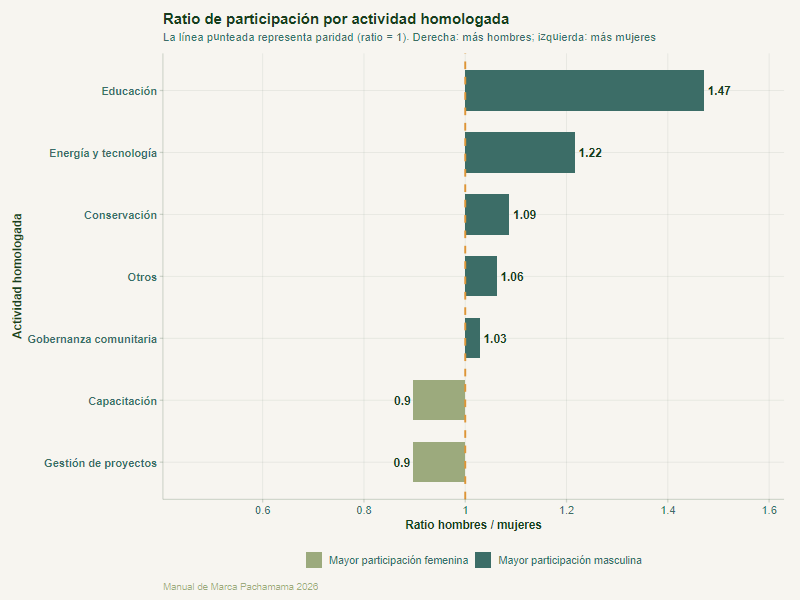

In [26]:


# ------------------------------------------------------------
# 1. Preparación
# - eliminar duplicados
# - convertir variables numéricas
# ------------------------------------------------------------
Asambleas_0 <- Asambleas_0 %>%
  distinct(X_uuid, .keep_all = TRUE) %>%
  mutate(
    Numero_hombres = as.numeric(Numero_hombres),
    Numero_mujeres = as.numeric(Numero_mujeres)
  )

# ------------------------------------------------------------
# 2. Calcular ratio por Decision_homologada
# ratio = hombres / mujeres
# delta_ratio = ratio - 1
#   > 0  -> más hombres
#   < 0  -> más mujeres
# ------------------------------------------------------------
ratio_participacion <- Asambleas_0 %>%
  filter(
    !is.na(Decision_homologada),
    Decision_homologada != "",
    !(is.na(Numero_hombres) & is.na(Numero_mujeres))
  ) %>%
  group_by(Decision_homologada) %>%
  summarise(
    Conteo = n(),
    hombres = sum(Numero_hombres, na.rm = TRUE),
    mujeres = sum(Numero_mujeres, na.rm = TRUE),
    ratio_H_M = ifelse(mujeres == 0, NA_real_, hombres / mujeres),
    .groups = "drop"
  ) %>%
  filter(Conteo > 1, !is.na(ratio_H_M)) %>%
  mutate(
    delta_ratio = ratio_H_M - 1,
    direccion = case_when(
      delta_ratio > 0 ~ "Mayor participación masculina",
      delta_ratio < 0 ~ "Mayor participación femenina",
      TRUE ~ "Paridad"
    )
  ) %>%
  arrange(delta_ratio) %>%
  mutate(
    Decision_homologada = factor(Decision_homologada, levels = Decision_homologada)
  )

ratio_participacion

# ------------------------------------------------------------
# 3. Gráfico divergente desde 1
# - la barra sale desde la línea de paridad
# - derecha: más hombres
# - izquierda: más mujeres
# ------------------------------------------------------------
limite <- max(abs(ratio_participacion$delta_ratio), na.rm = TRUE) * 1.15

ggplot(
  ratio_participacion,
  aes(x = Decision_homologada, y = delta_ratio, fill = direccion)
) +
  geom_col(width = 0.65) +
  geom_vline(xintercept = NULL) +
  geom_hline(yintercept = 0, linetype = "dashed", color = PAL$ave, linewidth = 0.9) +
  geom_text(
    aes(
      label = round(ratio_H_M, 2),
      hjust = ifelse(delta_ratio >= 0, -0.15, 1.15)
    ),
    fontface = "bold",
    size = 4.2,
    color = PAL$hoja
  ) +
  scale_fill_manual(
    values = c(
      "Mayor participación masculina" = PAL$rio,
      "Mayor participación femenina" = PAL$arcilla,
      "Paridad" = PAL$cielo
    )
  ) +
  scale_y_continuous(
    limits = c(-limite, limite),
    breaks = pretty_breaks(n = 7),
    labels = function(x) round(x + 1, 2),
    expand = expansion(mult = c(0.05, 0.08))
  ) +
  coord_flip() +
  labs(
    title = "Ratio de participación por actividad homologada",
    subtitle = "La línea punteada representa paridad (ratio = 1). Derecha: más hombres; izquierda: más mujeres",
    x = "Actividad homologada",
    y = "Ratio hombres / mujeres",
    fill = NULL,
    caption = "Manual de Marca Pachamama 2026"
  ) +
  theme_pachamama(base_size = 13, legend_pos = "bottom") +
  theme(
    axis.text.y = element_text(face = "bold"),
    plot.title = element_text(face = "bold")
  )

## 3.4. Generación de capacidades

### Homologar valores

In [27]:


Capacitaciones <- Capacitaciones %>%
  mutate(
    Capacidad_adquirida_original = Capacidad_adquirida,
    
    Capacidad_adquirida = Capacidad_adquirida %>%
      str_squish() %>%
      stri_trans_general("Latin-ASCII") %>%
      str_to_lower(),
    
    Capacidad_adquirida_homologada = case_when(
      
      # 1. Dron
      str_detect(Capacidad_adquirida, "dron|vuelo") ~ 
        "Manejo de drones",
      
      # 2. Cámaras trampa
      str_detect(Capacidad_adquirida, "camara trampa|camaras trampa|camara$|camaras$|colocacion de camara|instalacion de la camara|configuracion|revision de camaras") ~ 
        "Manejo de cámaras trampa",
      
      # 3. GPS
      str_detect(Capacidad_adquirida, "gps") ~ 
        "Manejo de GPS",
      
      # 4. Monitoreo y registro
      str_detect(Capacidad_adquirida, "monitoreo|monitoreos|formulario|verificacion|registro") ~ 
        "Monitoreo y registro de datos",
      
      # 5. Herramientas digitales
      str_detect(Capacidad_adquirida, "forest watcher|forest wacher|programa|instalacion del programa") ~ 
        "Herramientas digitales de monitoreo",
      
      # 6. Comunicación
      str_detect(Capacidad_adquirida, "comunicacion|audio vision|artevision|plan de rodaje|fotograf|fotos|camaras digitales") ~ 
        "Comunicación y documentación audiovisual",
      
      # 7. Talleres generales
      str_detect(Capacidad_adquirida, "taller|capacitacion|intercambio de conocimientos|ensenanza") ~ 
        "Capacitación general e intercambio de conocimientos",
      
      # 8. Liderazgo / planificación
      str_detect(Capacidad_adquirida, "liderar|lider|planificacion|coordinacion") ~ 
        "Planificación, coordinación y liderazgo",
      
      # 9. Recursos / territorio / conservación
      str_detect(Capacidad_adquirida, "acuerdo de manejo|recursos forestales|conservacion|lindero|limite|territorio|vision") ~ 
        "Gestión de recursos y territorio",
      
      # 10. Otros técnicos
      TRUE ~ 
        "Otros conocimientos técnicos"
    )
  )

In [28]:

Capacitaciones <- Capacitaciones %>%
  mutate(
    Capacidad_adquirida_original = Capacidad_adquirida,
    
    Capacidad_adquirida = Capacidad_adquirida %>%
      str_squish() %>%
      stri_trans_general("Latin-ASCII") %>%
      str_to_lower(),
    
    categoria = case_when(
      
      # 1. Tecnologías (dron, GPS, cámaras, software)
      str_detect(Capacidad_adquirida, "dron|vuelo|gps|camara|camaras|forest watcher|forest wacher|programa|software") ~ 
        "Tecnologías",
      
      # 2. Monitoreo (registro, formularios, instalación, revisión)
      str_detect(Capacidad_adquirida, "monitoreo|monitoreos|formulario|registro|verificacion|instalacion|colocacion|configuracion|revision") ~ 
        "Monitoreo",
      
      # 3. Conservación (territorio, biodiversidad, acuerdos)
      str_detect(Capacidad_adquirida, "conservacion|recursos forestales|manejo de recursos|territorio|lindero|limite") ~ 
        "Conservación",
      
      # 4. Comunicación (audio, video, fotografía, rodaje)
      str_detect(Capacidad_adquirida, "comunicacion|audio|video|foto|fotograf|rodaje|artevision|camaras digitales") ~ 
        "Comunicación",
      
      # 5. Intercambio de conocimientos (talleres, capacitaciones, enseñanza)
      str_detect(Capacidad_adquirida, "taller|capacitacion|intercambio|ensenanza") ~ 
        "Intercambio",
      
      # 6. Gestión (planificación, coordinación, liderazgo)
      str_detect(Capacidad_adquirida, "planificacion|coordinacion|lider|organizacion|plenaria|vision") ~ 
        "Gestión",
      
      # 7. Producción (piscinas, alevines, prácticas productivas)
      str_detect(Capacidad_adquirida, "piscina|alevines|produccion") ~ 
        "Producción",
      
      # 8. Otros
      TRUE ~ "Otros"
    )
  )

### Total de capacitaciones por categoría

In [32]:

# =========================================================
# 1. Preparar datos
# =========================================================

capacitaciones_anual <- Capacitaciones %>%
  mutate(
    Fecha = as.Date(Fecha),
    anio  = lubridate::year(Fecha),
    categoria = trimws(categoria)
  ) %>%
  filter(!is.na(anio), !is.na(categoria), categoria != "")

# =========================================================
# 2. Opcional: eliminar duplicados exactos por X_uuid
#    Útil porque en tus datos hay registros repetidos
# =========================================================

capacitaciones_anual <- capacitaciones_anual %>%
  distinct(X_uuid, .keep_all = TRUE)

# =========================================================
# 3. Conteo de capacitaciones por categoría y año
# =========================================================

conteo_categoria_anio <- capacitaciones_anual %>%
  count(anio, categoria, name = "n_capacitaciones") %>%
  arrange(anio, desc(n_capacitaciones))

conteo_categoria_anio

   anio    categoria n_capacitaciones
1  2023  Intercambio                2
2  2024  Tecnologías               17
3  2024 Comunicación                4
4  2024 Conservación                3
5  2025  Tecnologías               10
6  2025 Conservación                3
7  2025    Monitoreo                3
8  2025        Otros                3
9  2025 Comunicación                2
10 2025      Gestión                2
11 2025  Intercambio                2
12 2025   Producción                1

In [33]:
# =========================================================
# 4. Tabla en formato ancho
# =========================================================

tabla_categoria_anio <- conteo_categoria_anio %>%
  pivot_wider(
    names_from  = categoria,
    values_from = n_capacitaciones,
    values_fill = 0
  ) %>%
  arrange(anio)

tabla_categoria_anio

# A tibble: 3 × 9
   anio Intercambio Tecnologías Comunicación Conservación Monitoreo Otros Gestión Producción
  <dbl>       <int>       <int>        <int>        <int>     <int> <int>   <int>      <int>
1  2023           2           0            0            0         0     0       0          0
2  2024           0          17            4            3         0     0       0          0
3  2025           2          10            2            3         3     3       2          1

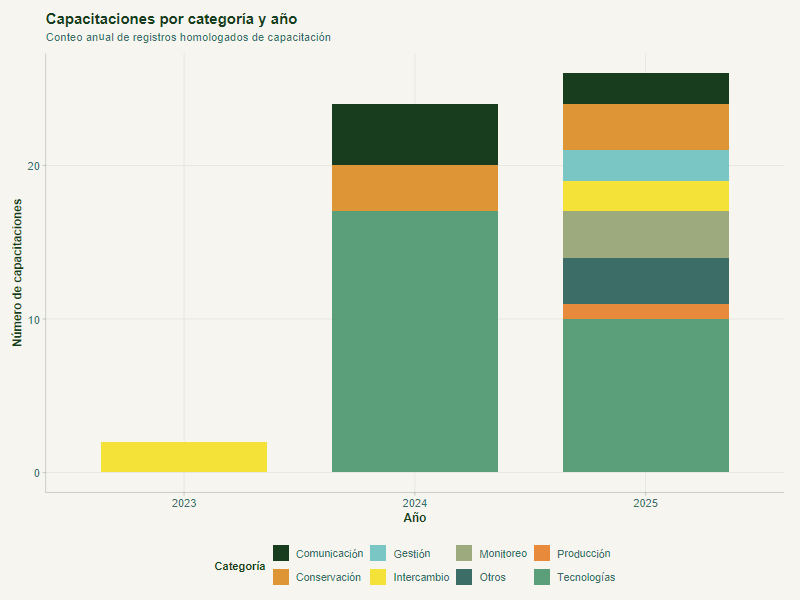

In [34]:
# =========================================================
# 5. Gráfico de barras apiladas por año
# =========================================================

ggplot(conteo_categoria_anio,
  aes(x = factor(anio), y = n_capacitaciones, fill = categoria)) +
geom_col(width = 0.72, color = NA) +
labs(
title = "Capacitaciones por categoría y año",
subtitle = "Conteo anual de registros homologados de capacitación",
x = "Año",
y = "Número de capacitaciones",
fill = "Categoría"
) +
scale_fill_pacha() +
theme_pachamama(base_size = 13, legend_pos = "bottom")

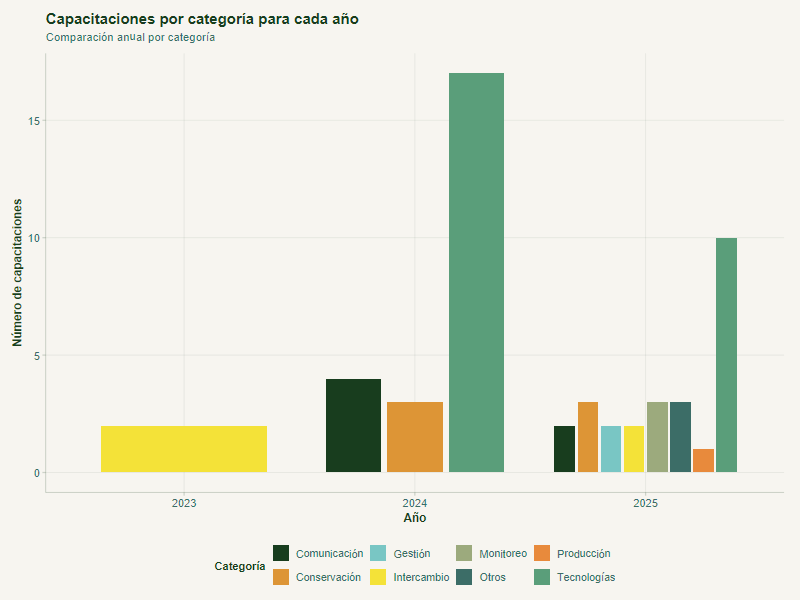

In [35]:
# =========================================================
# 6. Gráfico en barras agrupadas
# =========================================================

ggplot(conteo_categoria_anio,
  aes(x = factor(anio), y = n_capacitaciones, fill = categoria)) +
geom_col(position = position_dodge(width = 0.8), width = 0.72) +
labs(
title = "Capacitaciones por categoría para cada año",
subtitle = "Comparación anual por categoría",
x = "Año",
y = "Número de capacitaciones",
fill = "Categoría"
) +
scale_fill_pacha() +
theme_pachamama(base_size = 13, legend_pos = "bottom")

### Horas-Persona capacitación

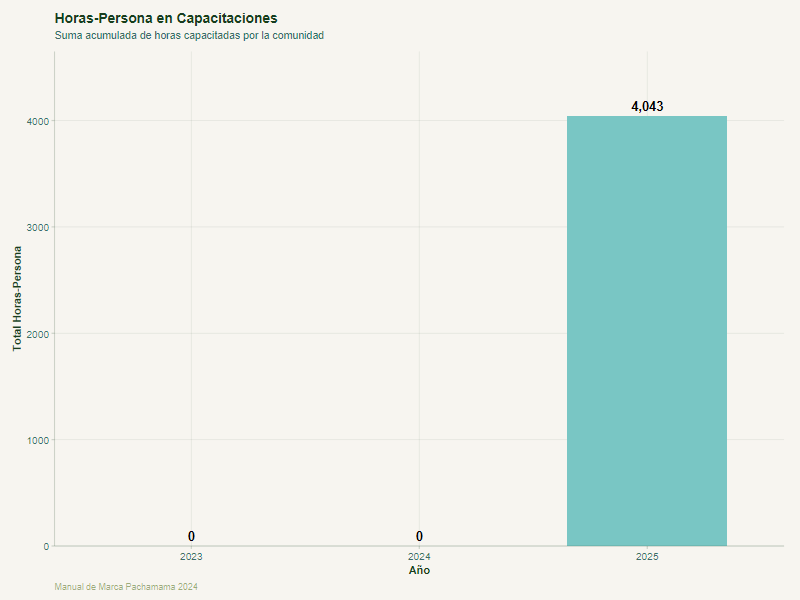

In [57]:
Capacitaciones$Hora_persona_mujer = Capacitaciones$Numero_mujeres * Capacitaciones$Numero_horas_capacitacion
Capacitaciones$Hora_persona_hombre = Capacitaciones$Numero_hombres * Capacitaciones$Numero_horas_capacitacion
# 1. Cálculo de Horas-Persona y preparación de datos mensuales


# 1. Preparar los datos de Horas-Persona
Capacitaciones_df <- Capacitaciones %>%
  mutate(
    # Aplicamos tus fórmulas
    HP_Mujer = Numero_mujeres * Numero_horas_capacitacion,
    HP_Hombre = Numero_hombres * Numero_horas_capacitacion,
    Mes = floor_date(as.Date(Fecha), "month")
  ) %>%
  group_by(Mes) %>%
  summarise(
    Horas_Mujeres = sum(HP_Mujer, na.rm = TRUE),
    Horas_Hombres = sum(HP_Hombre, na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  arrange(Mes)




# 1. Preparar los datos anuales
horas_anuales <- Capacitaciones %>%
  #filter(Comunidad == "Wayusentsa")%>%
  mutate(
    # Calculamos horas-persona total por cada fila
    HP_fila = (Numero_mujeres + Numero_hombres) * Numero_horas_capacitacion,
    # Extraemos el año
    Anio = as.factor(year(as.Date(Fecha)))
  ) %>%
  group_by(Anio) %>%
  summarise(Total_HP = sum(HP_fila, na.rm = TRUE), .groups = 'drop')

# 2. Generar el gráfico de barras
ggplot(horas_anuales, aes(x = Anio, y = Total_HP, fill = Anio)) +
  geom_col(width = 0.7, show.legend = FALSE) +
  # Etiquetas sobre las barras para lectura rápida
  geom_text(aes(label = scales::comma(Total_HP)), 
            vjust = -0.5, 
            fontface = "bold", 
            size = 4.5) +
  scale_fill_pacha() + # Colores institucionales
  labs(
    title = "Horas-Persona en Capacitaciones",
    subtitle = "Suma acumulada de horas capacitadas por la comunidad",
    x = "Año",
    y = "Total Horas-Persona",
    caption = "Manual de Marca Pachamama 2024"
  ) +
  # Ajustar el límite superior para que no se corte la etiqueta
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  theme_pachamama() +
  theme(text = element_text(family = "sans"))

In [44]:


# =========================================================
# 1. Crear total de capacitados y horas-persona de capacitación
# =========================================================

Capacitaciones_proc <- Capacitaciones %>%
  mutate(
    Fecha = as.Date(Fecha),
    anio  = year(Fecha),

    # Regla:
    # - si uno es NA y el otro tiene valor -> reemplazar NA por 0
    # - si ambos son NA -> mantener NA
    total_capacitados = case_when(
      is.na(Numero_hombres) & is.na(Numero_mujeres) ~ NA_real_,
      TRUE ~ coalesce(as.numeric(Numero_hombres), 0) + coalesce(as.numeric(Numero_mujeres), 0)
    ),

    # Nombre recomendado: horas_persona_capacitacion
    horas_persona_capacitacion = case_when(
      is.na(total_capacitados) | is.na(Numero_horas_capacitacion) ~ NA_real_,
      TRUE ~ total_capacitados * as.numeric(Numero_horas_capacitacion)
    )
  ) %>%filter(!is.na(horas_persona_capacitacion))

# Verificar resultado
Capacitaciones_proc %>%
  select(
    Fecha, categoria, Numero_hombres, Numero_mujeres,
    total_capacitados, Numero_horas_capacitacion,
    horas_persona_capacitacion
  ) %>%
    head(15)

        Fecha    categoria Numero_hombres Numero_mujeres total_capacitados Numero_horas_capacitacion horas_persona_capacitacion
1  2025-03-11    Monitoreo             10              6                16                         4                         64
2  2025-03-05 Conservación             17             16                33                         2                         66
3  2025-03-08      Gestión              4              8                12                         2                         24
4  2025-03-08    Monitoreo              4              8                12                         2                         24
5  2025-03-11 Conservación             10             12                22                         3                         66
6  2025-03-12  Tecnologías             10             12                22                         3                         66
7  2025-04-04  Tecnologías              4              1                 5                         4    

In [45]:
# =========================================================
# 2. Agregar por categoría
#    Aquí se resume el esfuerzo total de capacitación
# =========================================================

resumen_categoria <- Capacitaciones_proc %>%
  distinct(X_uuid, .keep_all = TRUE) %>%   # evita duplicados
  filter(!is.na(categoria), categoria != "") %>%
  group_by(categoria) %>%
  summarise(
    n_capacitaciones = n(),
    total_capacitados = sum(total_capacitados, na.rm = TRUE),
    total_horas_persona = sum(horas_persona_capacitacion, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(total_horas_persona))

resumen_categoria

# A tibble: 8 × 4
  categoria    n_capacitaciones total_capacitados total_horas_persona
  <chr>                   <int>             <dbl>               <dbl>
1 Gestión                     2               312                2424
2 Tecnologías                10               111                 429
3 Conservación                3                85                 312
4 Intercambio                 2                32                 258
5 Otros                       3                41                 174
6 Comunicación                2                21                 168
7 Monitoreo                   3                34                 163
8 Producción                  1                31                  62

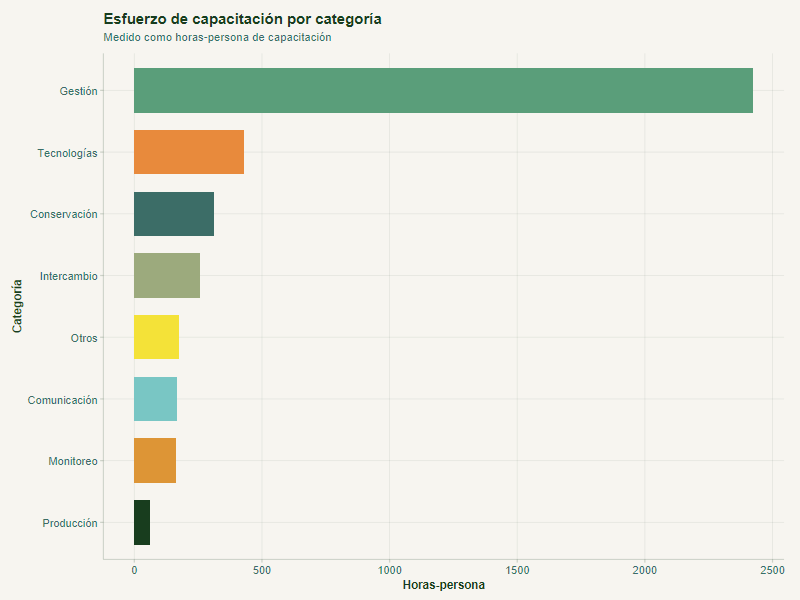

In [46]:
# =========================================================
# 3. Gráfica de barras por categoría
#    Métrica: horas-persona de capacitación
# =========================================================

ggplot(
  resumen_categoria %>%
    mutate(categoria = reorder(categoria, total_horas_persona)),
  aes(x = categoria, y = total_horas_persona, fill = categoria)
) +
  geom_col(width = 0.72, show.legend = FALSE) +
  coord_flip() +
  labs(
    title = "Esfuerzo de capacitación por categoría",
    subtitle = "Medido como horas-persona de capacitación",
    x = "Categoría",
    y = "Horas-persona"
  ) +
  scale_fill_pacha() +
  theme_pachamama(base_size = 13, legend_pos = "none")

### Diversidad de capacitaciones

In [55]:

# =========================================================
# 1. Preparar datos (horas-persona ya definidas correctamente)
# =========================================================

cap_proc <- Capacitaciones %>%
  distinct(X_uuid, .keep_all = TRUE) %>%
  mutate(
    Fecha = as.Date(Fecha),
    anio  = year(Fecha),

    total_capacitados = case_when(
      is.na(Numero_hombres) & is.na(Numero_mujeres) ~ NA_real_,
      TRUE ~ coalesce(as.numeric(Numero_hombres), 0) +
             coalesce(as.numeric(Numero_mujeres), 0)
    ),

    horas_persona = case_when(
      is.na(total_capacitados) | is.na(Numero_horas_capacitacion) ~ NA_real_,
      TRUE ~ total_capacitados * as.numeric(Numero_horas_capacitacion)
    )
  ) %>%
  filter(!is.na(anio), !is.na(categoria), categoria != "", !is.na(horas_persona))

# =========================================================
# 2. Matriz: año × categoría (abundancia = horas_persona)
# =========================================================

matriz <- cap_proc %>%
  group_by(anio, categoria) %>%
  summarise(horas_persona = sum(horas_persona), .groups = "drop") %>%
  pivot_wider(
    names_from = categoria,
    values_from = horas_persona,
    values_fill = 0
  )

# =========================================================
# 3. Calcular Shannon y número de Hill (q = 1)
# =========================================================

diversidad_anual <- matriz %>%
  rowwise() %>%
  mutate(
    total = sum(c_across(-anio)),
    p = list(c_across(-anio) / total),

    # Shannon
    shannon = -sum(p[[1]] * log(p[[1]] + 1e-12)),

    # Hill (q = 1)
    hill_q1 = exp(shannon)
  ) %>%
  ungroup() %>%
  select(anio, shannon, hill_q1) %>%
  arrange(anio)

diversidad_anual

# A tibble: 1 × 3
   anio shannon hill_q1
  <dbl>   <dbl>   <dbl>
1  2025   0.133    1.14

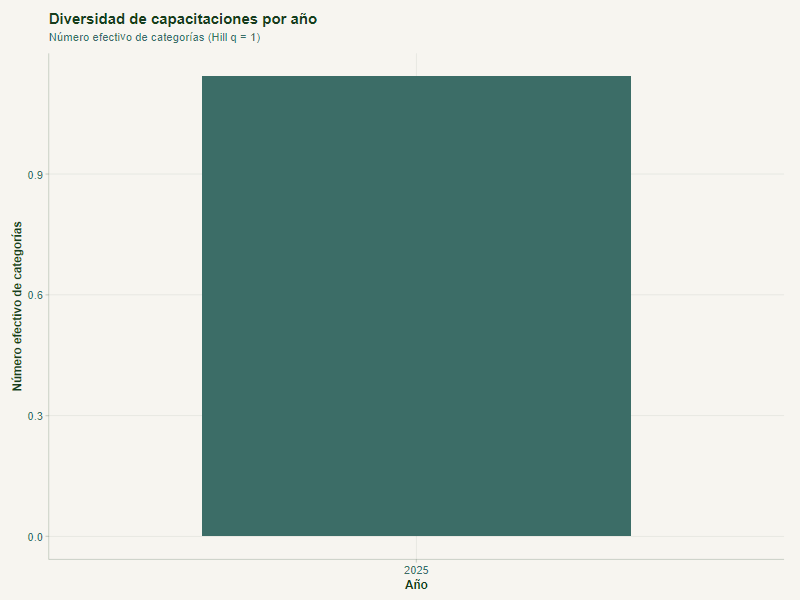

In [56]:


ggplot(diversidad_anual, aes(x = factor(anio), y = hill_q1)) +
  geom_col(fill = PAL$rio, width = 0.7) +
  labs(
    title = "Diversidad de capacitaciones por año",
    subtitle = "Número efectivo de categorías (Hill q = 1)",
    x = "Año",
    y = "Número efectivo de categorías"
  ) +
  theme_pachamama(base_size = 13, legend_pos = "none")

### Capacitaciones por Género

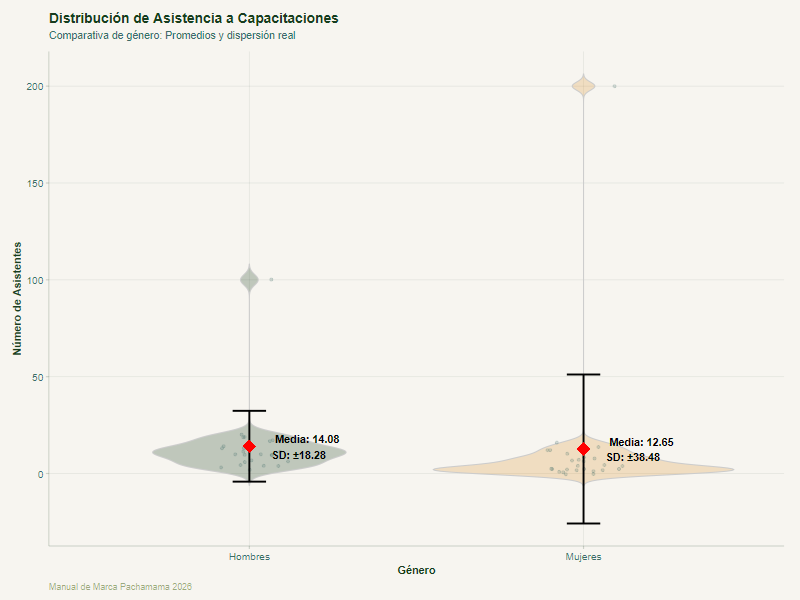

In [30]:

# 1. Pre-procesamiento: Limpieza de NAs y transformación a formato largo
capacitaciones_limpias <- Capacitaciones %>%
  select(Numero_hombres, Numero_mujeres) %>%
  # Eliminamos filas donde ambos campos sean NA para no falsear el violín
  drop_na(Numero_hombres, Numero_mujeres) 

# 2. Cálculo de estadísticos para las etiquetas
resumen_stats_cap <- capacitaciones_limpias %>%
  pivot_longer(cols = everything(), names_to = "Genero", values_to = "Cantidad") %>%
  mutate(Genero = if_else(Genero == "Numero_hombres", "Hombres", "Mujeres")) %>%
  group_by(Genero) %>%
  summarise(
    Media = mean(Cantidad),
    SD = sd(Cantidad),
    .groups = 'drop'
  )

# 3. Preparación de datos para la gráfica
cap_long <- capacitaciones_limpias %>%
  pivot_longer(cols = everything(), names_to = "Genero", values_to = "Cantidad") %>%
  mutate(Genero = if_else(Genero == "Numero_hombres", "Hombres", "Mujeres"))

# 4. Generación de la gráfica de Violín
ggplot(cap_long, aes(x = Genero, y = Cantidad, fill = Genero)) +
  # Fondo de Violín (Densidad de participación)
  geom_violin(alpha = 0.25, color = "gray80", trim = FALSE) +
  
  # Puntos (Jitter) para ver cada capacitación individual
  geom_point(position = position_jitter(width = 0.12), 
             alpha = 0.2, color = "#3c6d67", size = 1.2) +
  
  # Barra de Desviación Estándar (±1 SD)
  geom_errorbar(data = resumen_stats_cap, 
                aes(y = Media, ymin = Media - SD, ymax = Media + SD), 
                width = 0.1, color = "black", linewidth = 0.9) +
  
  # Punto del Promedio (Rombo Rojo)
  geom_point(data = resumen_stats_cap, aes(y = Media), 
             shape = 18, size = 6, color = "red") +
  
  # Etiquetas de texto con valores redondeados
  geom_text(data = resumen_stats_cap, 
            aes(y = Media, label = paste0("Media: ", round(Media, 2), 
                                          "\nSD: ±", round(SD, 2))),
            hjust = -0.4, vjust = 0.5, size = 3.8, fontface = "bold") +
  
  scale_fill_pacha() + 
  labs(
    title = "Distribución de Asistencia a Capacitaciones",
    subtitle = "Comparativa de género: Promedios y dispersión real",
    x = "Género",
    y = "Número de Asistentes",
    caption = "Manual de Marca Pachamama 2026"
  ) +
  theme_pachamama() +
  theme(legend.position = "none")

In [59]:


# ------------------------------------------------------------
# 1. Preparación
# - eliminar duplicados
# - convertir variables numéricas
# ------------------------------------------------------------
Capacitaciones_0 <- Capacitaciones %>%
  distinct(X_uuid, .keep_all = TRUE) %>%
  mutate(
    Numero_hombres = as.numeric(Numero_hombres),
    Numero_mujeres = as.numeric(Numero_mujeres)
  )

# ------------------------------------------------------------
# 2. Calcular ratio por categoría de capacitación
# ratio = hombres / mujeres
# delta_ratio = ratio - 1
#   > 0  -> más hombres
#   < 0  -> más mujeres
# Regla:
# - si ambos son NA en un registro, se excluye
# - si una de las dos variables es NA y la otra tiene valor,
#   el NA se reemplaza por 0 para la suma
# ------------------------------------------------------------
ratio_capacitacion_categoria <- Capacitaciones_0 %>%
  filter(
    !is.na(categoria),
    categoria != "",
    !(is.na(Numero_hombres) & is.na(Numero_mujeres))
  ) %>%
  mutate(
    hombres_fila = case_when(
      is.na(Numero_hombres) & !is.na(Numero_mujeres) ~ 0,
      TRUE ~ Numero_hombres
    ),
    mujeres_fila = case_when(
      is.na(Numero_mujeres) & !is.na(Numero_hombres) ~ 0,
      TRUE ~ Numero_mujeres
    )
  ) %>%
  group_by(categoria) %>%
  summarise(
    Conteo = n(),
    hombres = sum(hombres_fila, na.rm = TRUE),
    mujeres = sum(mujeres_fila, na.rm = TRUE),
    ratio_H_M = ifelse(mujeres == 0, NA_real_, hombres / mujeres),
    .groups = "drop"
  ) %>%
  filter(Conteo > 0, !is.na(ratio_H_M)) %>%
  mutate(
    delta_ratio = ratio_H_M - 1,
    direccion = case_when(
      delta_ratio > 0 ~ "Mayor participación masculina",
      delta_ratio < 0 ~ "Mayor participación femenina",
      TRUE ~ "Paridad"
    )
  ) %>%
  arrange(delta_ratio) %>%
  mutate(
    categoria = factor(categoria, levels = categoria)
  )

ratio_capacitacion_categoria

# A tibble: 8 × 7
  categoria    Conteo hombres mujeres ratio_H_M delta_ratio direccion                    
  <fct>         <int>   <dbl>   <dbl>     <dbl>       <dbl> <chr>                        
1 Gestión           2     104     208      0.5       -0.5   Mayor participación femenina 
2 Producción        1      17      14      1.21       0.214 Mayor participación masculina
3 Conservación      3      47      38      1.24       0.237 Mayor participación masculina
4 Tecnologías      10      82      29      2.83       1.83  Mayor participación masculina
5 Monitoreo         3      26       8      3.25       2.25  Mayor participación masculina
6 Otros             3      32       9      3.56       2.56  Mayor participación masculina
7 Intercambio       2      25       7      3.57       2.57  Mayor participación masculina
8 Comunicación      2      19       2      9.5        8.5   Mayor participación masculina

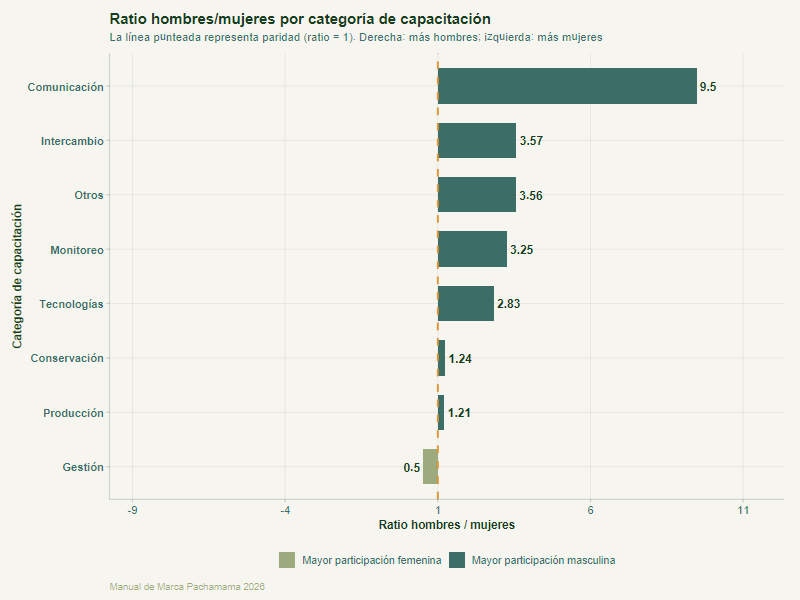

In [60]:
# ------------------------------------------------------------
# 3. Gráfico divergente desde 1
# - la barra sale desde la línea de paridad
# - derecha: más hombres
# - izquierda: más mujeres
# ------------------------------------------------------------
limite <- max(abs(ratio_capacitacion_categoria$delta_ratio), na.rm = TRUE) * 1.15

ggplot(
  ratio_capacitacion_categoria,
  aes(x = categoria, y = delta_ratio, fill = direccion)
) +
  geom_col(width = 0.65) +
  geom_hline(yintercept = 0, linetype = "dashed", color = PAL$ave, linewidth = 0.9) +
  geom_text(
    aes(
      label = round(ratio_H_M, 2),
      hjust = ifelse(delta_ratio >= 0, -0.15, 1.15)
    ),
    fontface = "bold",
    size = 4.2,
    color = PAL$hoja
  ) +
  scale_fill_manual(
    values = c(
      "Mayor participación masculina" = PAL$rio,
      "Mayor participación femenina" = PAL$arcilla,
      "Paridad" = PAL$cielo
    )
  ) +
  scale_y_continuous(
    limits = c(-limite, limite),
    breaks = pretty_breaks(n = 7),
    labels = function(x) round(x + 1, 2),
    expand = expansion(mult = c(0.05, 0.08))
  ) +
  coord_flip() +
  labs(
    title = "Ratio hombres/mujeres por categoría de capacitación",
    subtitle = "La línea punteada representa paridad (ratio = 1). Derecha: más hombres; izquierda: más mujeres",
    x = "Categoría de capacitación",
    y = "Ratio hombres / mujeres",
    fill = NULL,
    caption = "Manual de Marca Pachamama 2026"
  ) +
  theme_pachamama(base_size = 13, legend_pos = "bottom") +
  theme(
    axis.text.y = element_text(face = "bold"),
    plot.title = element_text(face = "bold")
  )

### Red de conceptos

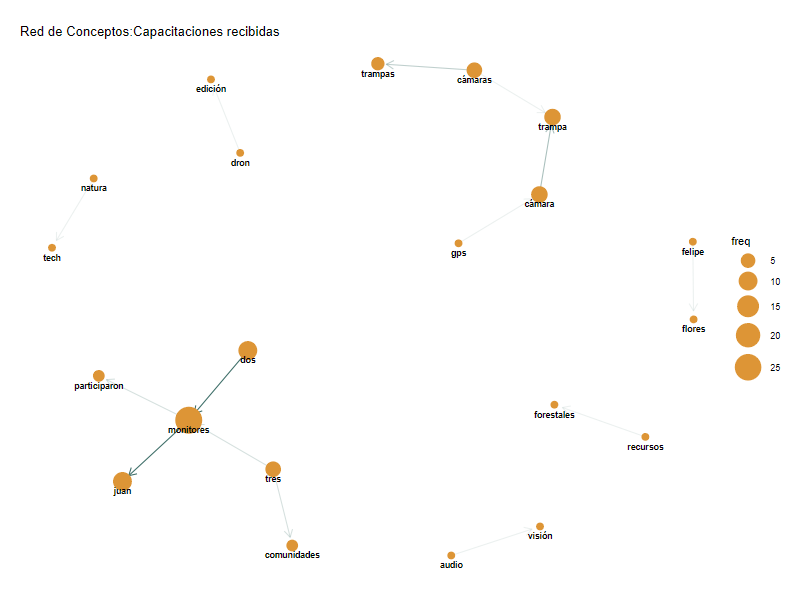

In [ ]:
stop_words_es <- data.frame(word = c("de", "la", "el", "en", "y", "a", "los", "las", "un", "una", 
                                     "con", "por", "para", "se", "del", "al", "lo", "su", "es", "una", "mas", "que"))

# 2. Procesamiento con limpieza de NAs
red_datos <- Capacitaciones %>%
  filter(!is.na(Capacidad_adquirida)) %>%
  mutate(texto = str_to_lower(Capacidad_adquirida) %>% str_replace_all("[^[:alpha:][:space:]]", "")) %>%
  unnest_tokens(bigrama, texto, token = "ngrams", n = 2) %>%
  # Al separar, si una frase tenía una sola palabra, el segundo valor será NA
  separate(bigrama, c("p1", "p2"), sep = " ") %>%
  # ELIMINAR LOS NAs (Aquí es donde se soluciona el error)
  filter(!is.na(p1), !is.na(p2)) %>%
  # Quitar palabras sin significado
  filter(!p1 %in% stop_words_es$word, !p2 %in% stop_words_es$word) %>%
  count(p1, p2, sort = TRUE) %>%
  filter(n > 1)

# 3. Ahora sí, crear el objeto de red
red_objeto <- graph_from_data_frame(red_datos)
freq_nodos <- bind_rows(
  red_datos %>% select(word = p1, n),
  red_datos %>% select(word = p2, n)
) %>%
  group_by(word) %>%
  summarise(freq = sum(n), .groups = "drop")


# 4. Graficar
set.seed(123)
red_objeto <- graph_from_data_frame(red_datos)

V(red_objeto)$freq <- freq_nodos$freq[match(V(red_objeto)$name, freq_nodos$word)]


ggraph(red_objeto, layout = "kk") +
  geom_edge_link(
    aes(edge_alpha = n),
    edge_colour = PAL$rio,
    arrow = arrow(length = unit(3, "mm")),
    end_cap = circle(3, "mm"),
    show.legend = FALSE
  ) +
  geom_node_point(
    aes(size = freq),
    color = PAL$ave
  ) +
  geom_node_text(
    aes(label = name),
    vjust = 1.8,
    size = 3,
    fontface = "bold"
  ) +
  scale_size(range = c(3, 12)) +
  labs(
    title = "Red de Conceptos:Capacitaciones recibidas",
  ) +
  theme_void() +
  theme(plot.margin = margin(20, 20, 20, 20))